正在读取数据...


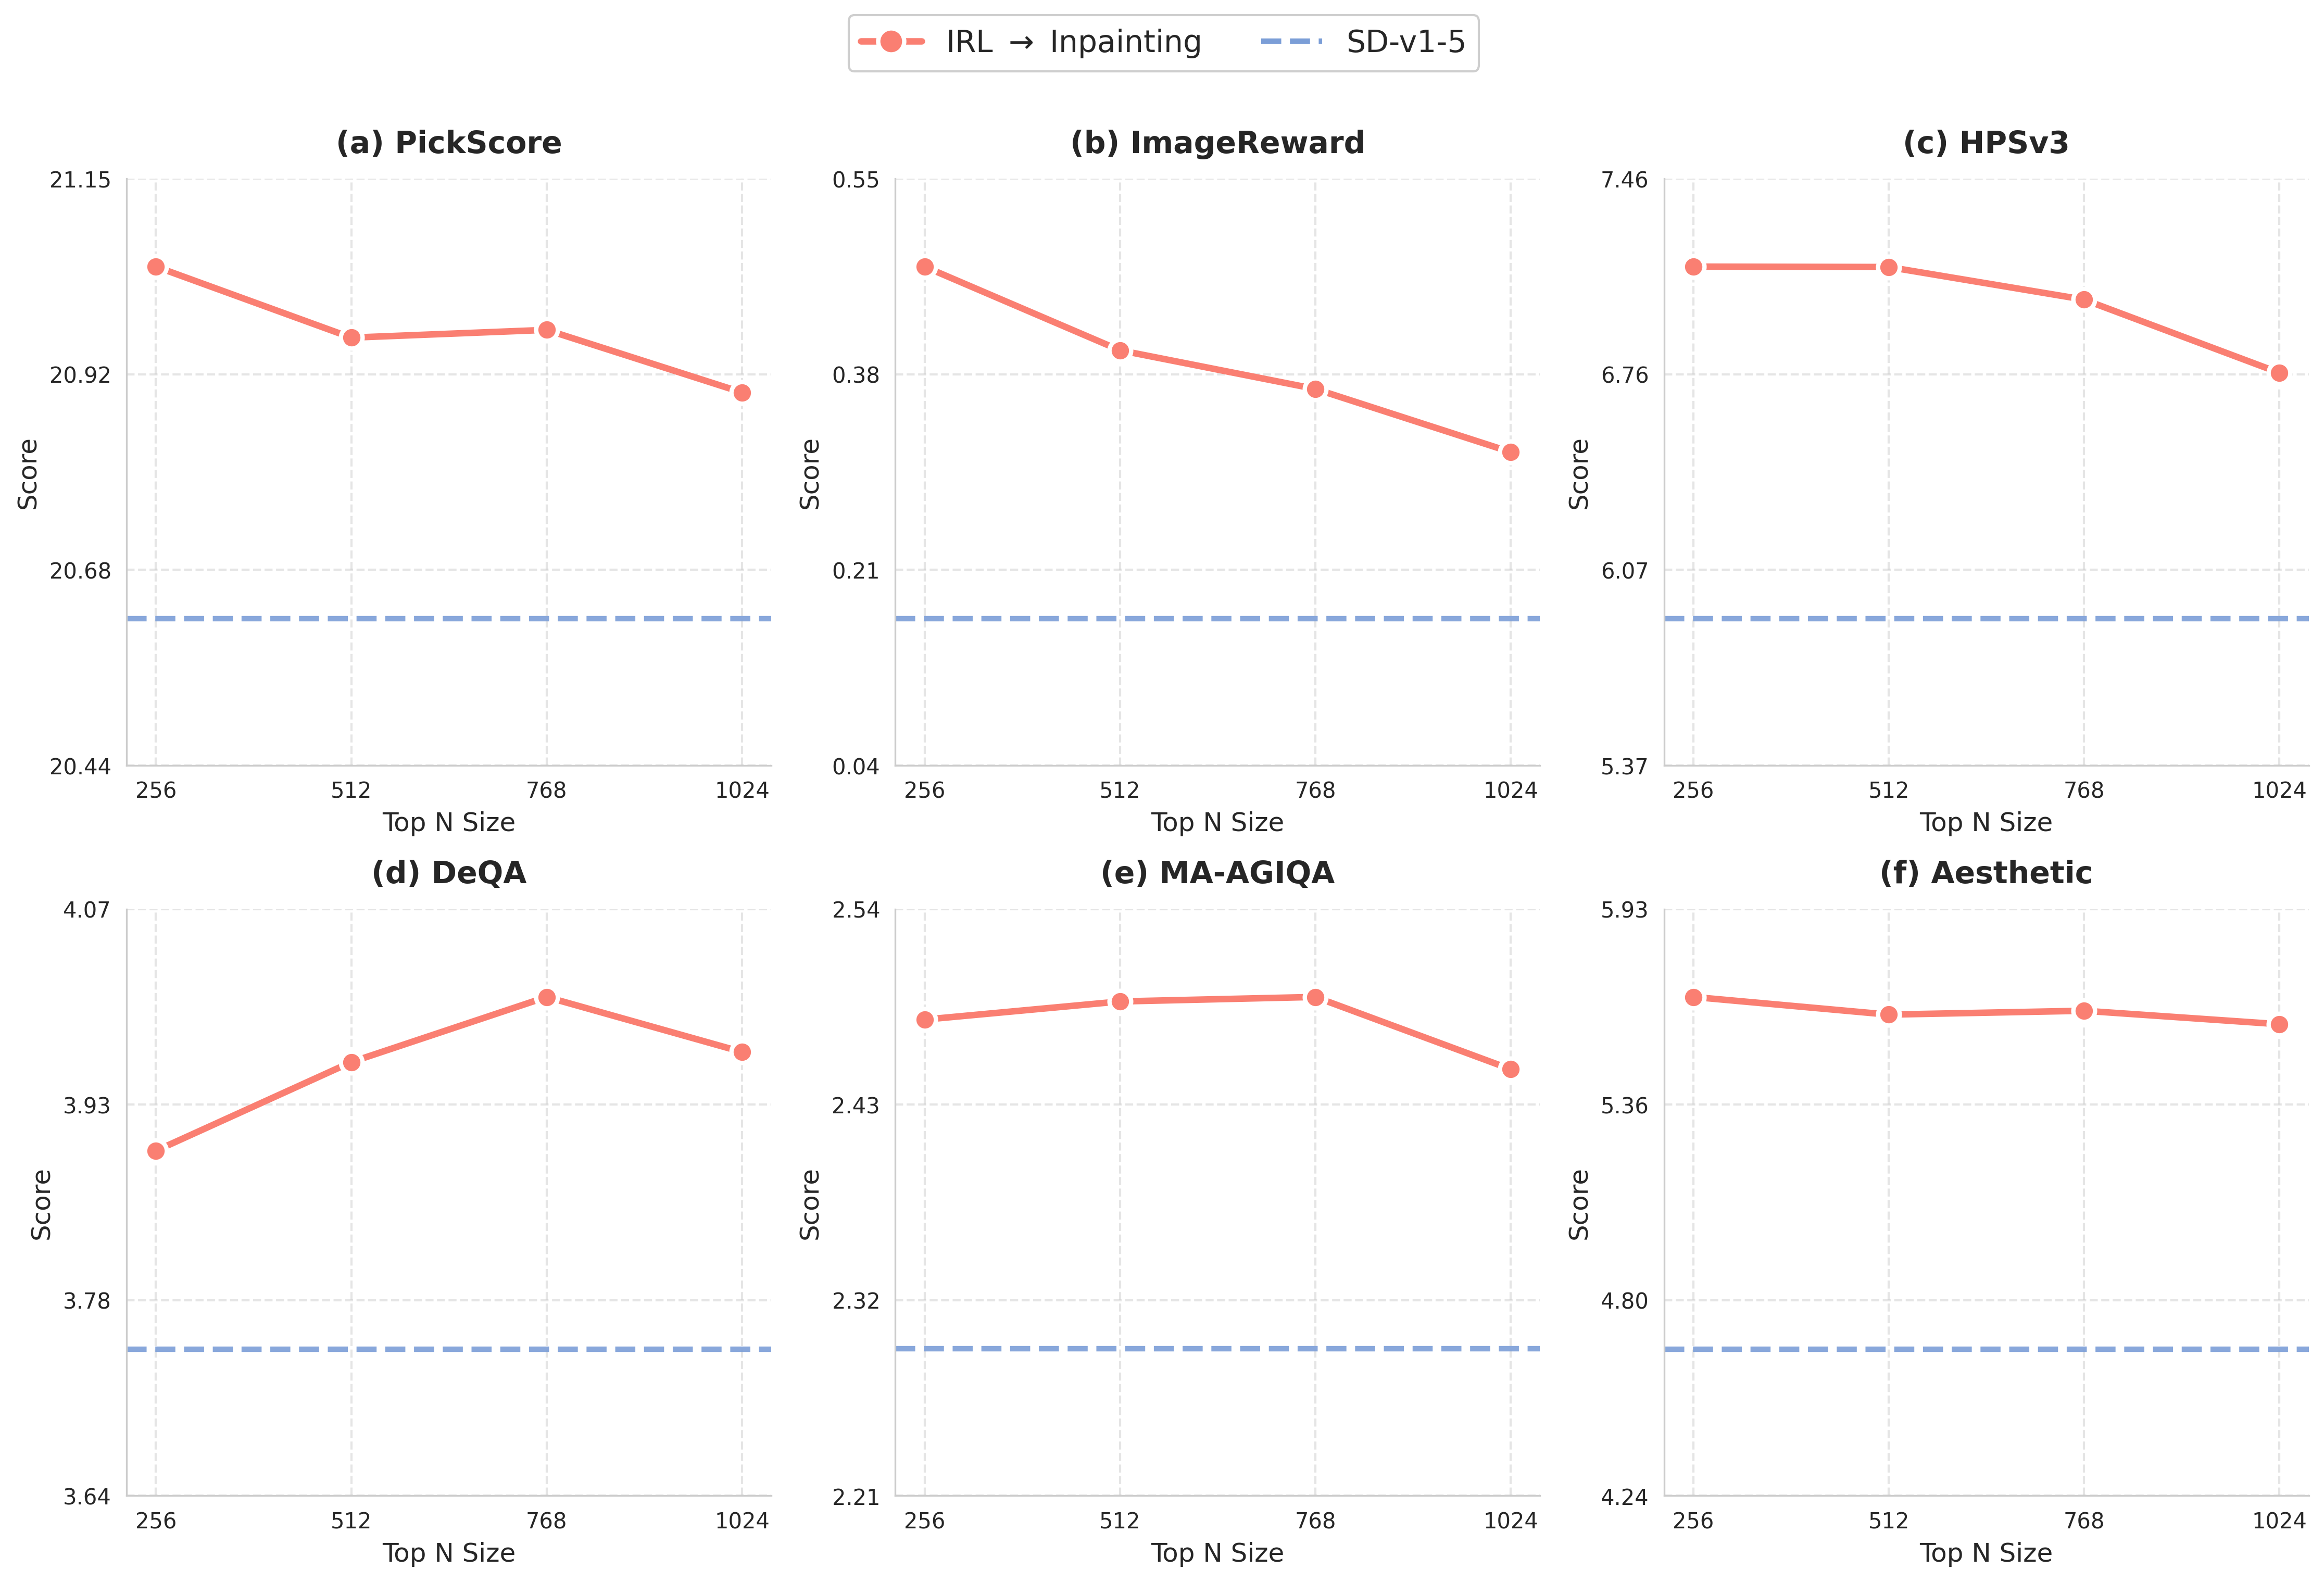

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, LinearLocator

# ================= 1. 数据配置 (保持不变) =================
base_score_dict = {
    "pickscore": 0.7930436655282974 * 26,
    "imagereward": 0.16912677358626388,
    "hpsv3": 5.892178298220038,
    "deqa": 3.745064453125,
    "ma-agiqa": 2.293051694869995,
    "aesthetic": 4.662666016578674
}

inpainting_score_dir = "/data_center/data2/dataset/chenwy/21164-data/diffusion-dpo/sd-v1-5/generate_images/pick_a_pic_v2/"
top_N_list = [256, 512, 768, 1024] 
ckpt = 800
all_metrics = ['pickscore', 'imagereward', 'hpsv3', 'deqa', 'ma-agiqa', 'aesthetic']

# ================= 2. 读取数据 (保持不变) =================
data_list = []
print("正在读取数据...")
for top_N in top_N_list:
    folder_name = f"irl_top_{top_N}_images_no_anime_colorfulness_pickscore_0.02-hpdv3_all_ckpt_1600-dpo_top_{top_N}_images_no_anime_colorfulness_pickscore_0.02-hpdv3_all_inpainting"
    json_path = os.path.join(inpainting_score_dir, folder_name, f"ckpt-{ckpt}", "average_scores.json")
    
    if os.path.exists(json_path):
        try:
            with open(json_path, 'r') as f:
                scores = json.load(f)
            for metric in all_metrics:
                if metric in scores:
                    val = scores[metric]
                    if metric == 'pickscore': val *= 26 
                    data_list.append({'top_N': top_N, 'metric': metric, 'score': val})
        except Exception as e:
            print(f"读取出错: {e}")
    else:
        print(f"Warning: {json_path} 不存在")

df = pd.DataFrame(data_list)

# (防止空数据报错的测试代码)
if df.empty:
    print("⚠️ 警告：未读取到数据，使用随机数据演示...")
    base_vals = [20.6, 0.15, 5.8, 3.7, 2.3, 4.6]
    for i, m in enumerate(all_metrics):
        for t in top_N_list:
            df = pd.concat([df, pd.DataFrame([{'top_N': t, 'metric': m, 'score': base_vals[i] + 0.1 + np.random.rand()*0.1}])], ignore_index=True)

# ================= 3. 绘图参数 =================
LINE_WIDTH = 3.0              
MARKER_SIZE = 10              
MARKER_EDGE_WIDTH = 2.0       
BASELINE_WIDTH = 2.5 # 加粗一点基准线
TITLE_FONTSIZE = 14           
AXIS_LABEL_FONTSIZE = 12      
LEGEND_FONTSIZE = 14          

sns.set_style("whitegrid")

colors = {
    'Method': '#fa7f72',   
    'Baseline': '#7b9ed7'  
}

metric_display_names = {
    'pickscore': 'PickScore',
    'imagereward': 'ImageReward',
    'hpsv3': 'HPSv3',
    'deqa': 'DeQA',
    'ma-agiqa': 'MA-AGIQA',
    'aesthetic': 'Aesthetic'
}

# ================= 4. 开始绘图 (核心修改) =================

fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=300)
axes = axes.flatten()

for idx, metric in enumerate(all_metrics):
    ax = axes[idx]
    metric_df = df[df['metric'] == metric]
    base_val = base_score_dict.get(metric)
    
    # --- A. 绘制 Baseline (虚线) ---
    if base_val is not None:
        ax.axhline(y=base_val, color=colors['Baseline'], linestyle='--', 
                   linewidth=BASELINE_WIDTH, alpha=0.9, label='Baseline')    
    
    # --- B. 绘制 Top N 曲线 ---
    current_scores = [] # 用于记录当前分数以便计算范围
    if not metric_df.empty:
        current_scores = metric_df['score'].values
        sns.lineplot(
            data=metric_df,
            x='top_N',
            y='score',
            marker='o',
            markersize=MARKER_SIZE,
            linewidth=LINE_WIDTH,
            color=colors['Method'],
            ax=ax,
            markeredgecolor='white',
            markeredgewidth=MARKER_EDGE_WIDTH,
            errorbar=None
        )

    # --- C. 动态计算 Y 轴范围 (将 Baseline 放在 1/4 处) ---
    if base_val is not None and len(current_scores) > 0:
        max_score = np.max(current_scores)
        
        # 计算数据的高度差
        # 如果曲线在 Baseline 之上 (通常情况)
        if max_score > base_val:
            data_height = max_score - base_val
        else:
            data_height = base_val - np.min(current_scores) # 罕见情况
            
        # 防止 data_height 为 0 (平直线)
        if data_height < 1e-4: data_height = base_val * 0.1
            
        # 逻辑：
        # 我们希望 (max_score - base_val) 占据画布高度的 60% (从 25% 到 85%)
        # total_span * 0.6 = data_height
        total_span = data_height / 0.6
        
        # 下限 = Baseline值 - 25% 的总跨度
        y_lim_bottom = base_val - (total_span * 0.25)
        # 上限 = 下限 + 总跨度
        y_lim_top = y_lim_bottom + total_span
        
        ax.set_ylim(bottom=y_lim_bottom, top=y_lim_top)

    # --- D. 标题与标签 ---
    metric_display = metric_display_names.get(metric, metric.upper())
    ax.set_title(f'({chr(97+idx)}) {metric_display}', 
                       fontsize=TITLE_FONTSIZE, fontweight='semibold', pad=12)
    ax.set_xlabel('Top N Size', fontsize=AXIS_LABEL_FONTSIZE, fontweight='medium')
    ax.set_ylabel('Score', fontsize=AXIS_LABEL_FONTSIZE, fontweight='medium')
    
    # 刻度设置
    ax.set_xticks(top_N_list)
    ax.yaxis.set_major_locator(LinearLocator(numticks=4))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    # 美化
    ax.grid(True, alpha=0.5, linestyle='--', linewidth=1)
    sns.despine(ax=ax, top=True, right=True)
    
    # 移除子图自带的图例，最后统一添加
    if ax.get_legend():
        ax.get_legend().remove()

# ================= 5. 统一图例 =================
handles = [
    plt.Line2D([0], [0], marker='o', color=colors['Method'], 
               label=r'IRL $\rightarrow$ Inpainting', linewidth=LINE_WIDTH, markersize=12,
               markerfacecolor=colors['Method'], 
               markeredgecolor='white', markeredgewidth=MARKER_EDGE_WIDTH),
    plt.Line2D([0], [0], linestyle='--', color=colors['Baseline'], 
               label='SD-v1-5', linewidth=BASELINE_WIDTH)
]

fig.legend(handles=handles, loc='center', ncol=2, 
          frameon=True, fontsize=LEGEND_FONTSIZE, bbox_to_anchor=(0.5, 0.99),
          framealpha=0.95, edgecolor='#cccccc', fancybox=True)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()